In [699]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [700]:
data = pd.read_csv("train.csv")
data.drop(columns = "Id", inplace = True)
data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [701]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [702]:
data.PoolQC.fillna(0, inplace = True)
data.PoolQC = data.PoolQC.map({0:0,'Ex':3,'Fa':1,'Gd':2})
data.PoolArea *= data.PoolQC
data.drop(columns = "PoolQC", inplace = True)

<Axes: xlabel='Fence', ylabel='SalePrice'>

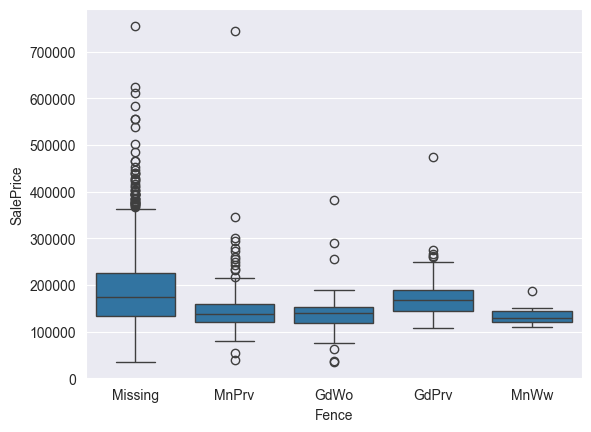

In [703]:
data.Fence.fillna('Missing',inplace = True)
sns.boxplot(x = "Fence", y = "SalePrice", data = data)

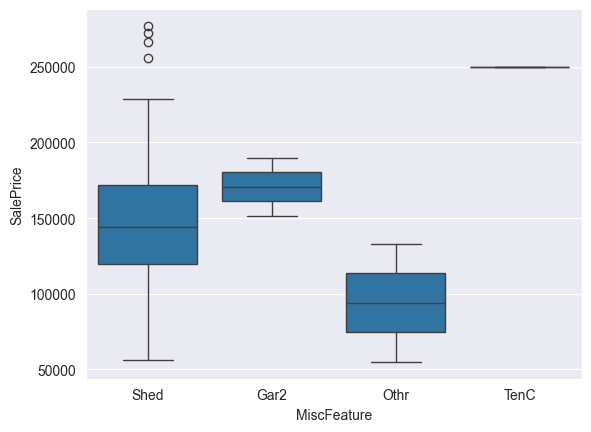

In [704]:
sns.boxplot(x = 'MiscFeature', y = 'SalePrice', data = data)
plt.show()

In [705]:
data["MiscFeature"].fillna('missing', inplace = True)

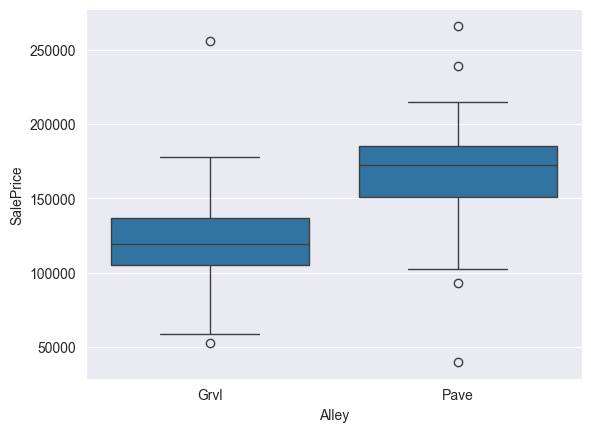

In [706]:
sns.boxplot(x = "Alley",y = "SalePrice", data = data)
data["Alley"].fillna('missing', inplace = True)

<Axes: xlabel='MasVnrType', ylabel='SalePrice'>

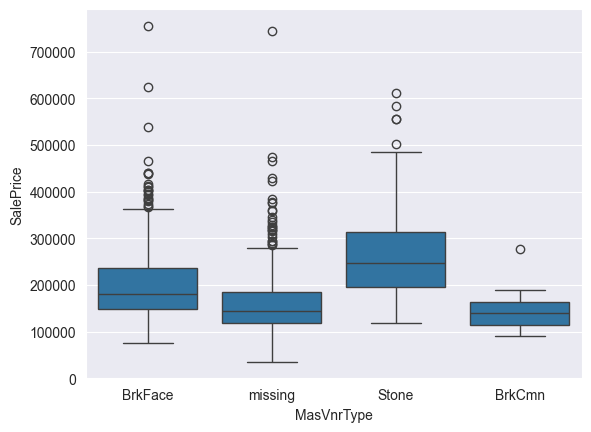

In [707]:
data["MasVnrType"] = data["MasVnrType"].fillna('missing')
sns.boxplot(x = "MasVnrType", y = "SalePrice", data = data)

<Axes: xlabel='FireplaceQu', ylabel='SalePrice'>

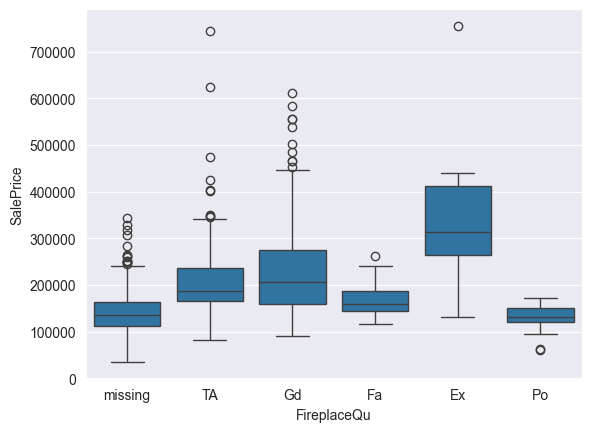

In [708]:
data["FireplaceQu"].fillna('missing', inplace = True)
sns.boxplot(x = "FireplaceQu" , y = "SalePrice", data = data)

In [709]:
data[data.select_dtypes("object").columns] = data.select_dtypes("object").fillna("missing")
data.fillna(0, inplace = True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [710]:
data.columns[data.isnull().sum() != 0]

Index([], dtype='object')

In [711]:
data["TotalBathroom"] = data["BsmtHalfBath"] + 0.5*data["BsmtHalfBath"] + data["HalfBath"] + 0.5*data["HalfBath"]
data.drop(columns = ["BsmtFullBath","BsmtHalfBath","FullBath","HalfBath"])

data["Age"] = data["YrSold"] - data["YearBuilt"] + data["MoSold"]/12

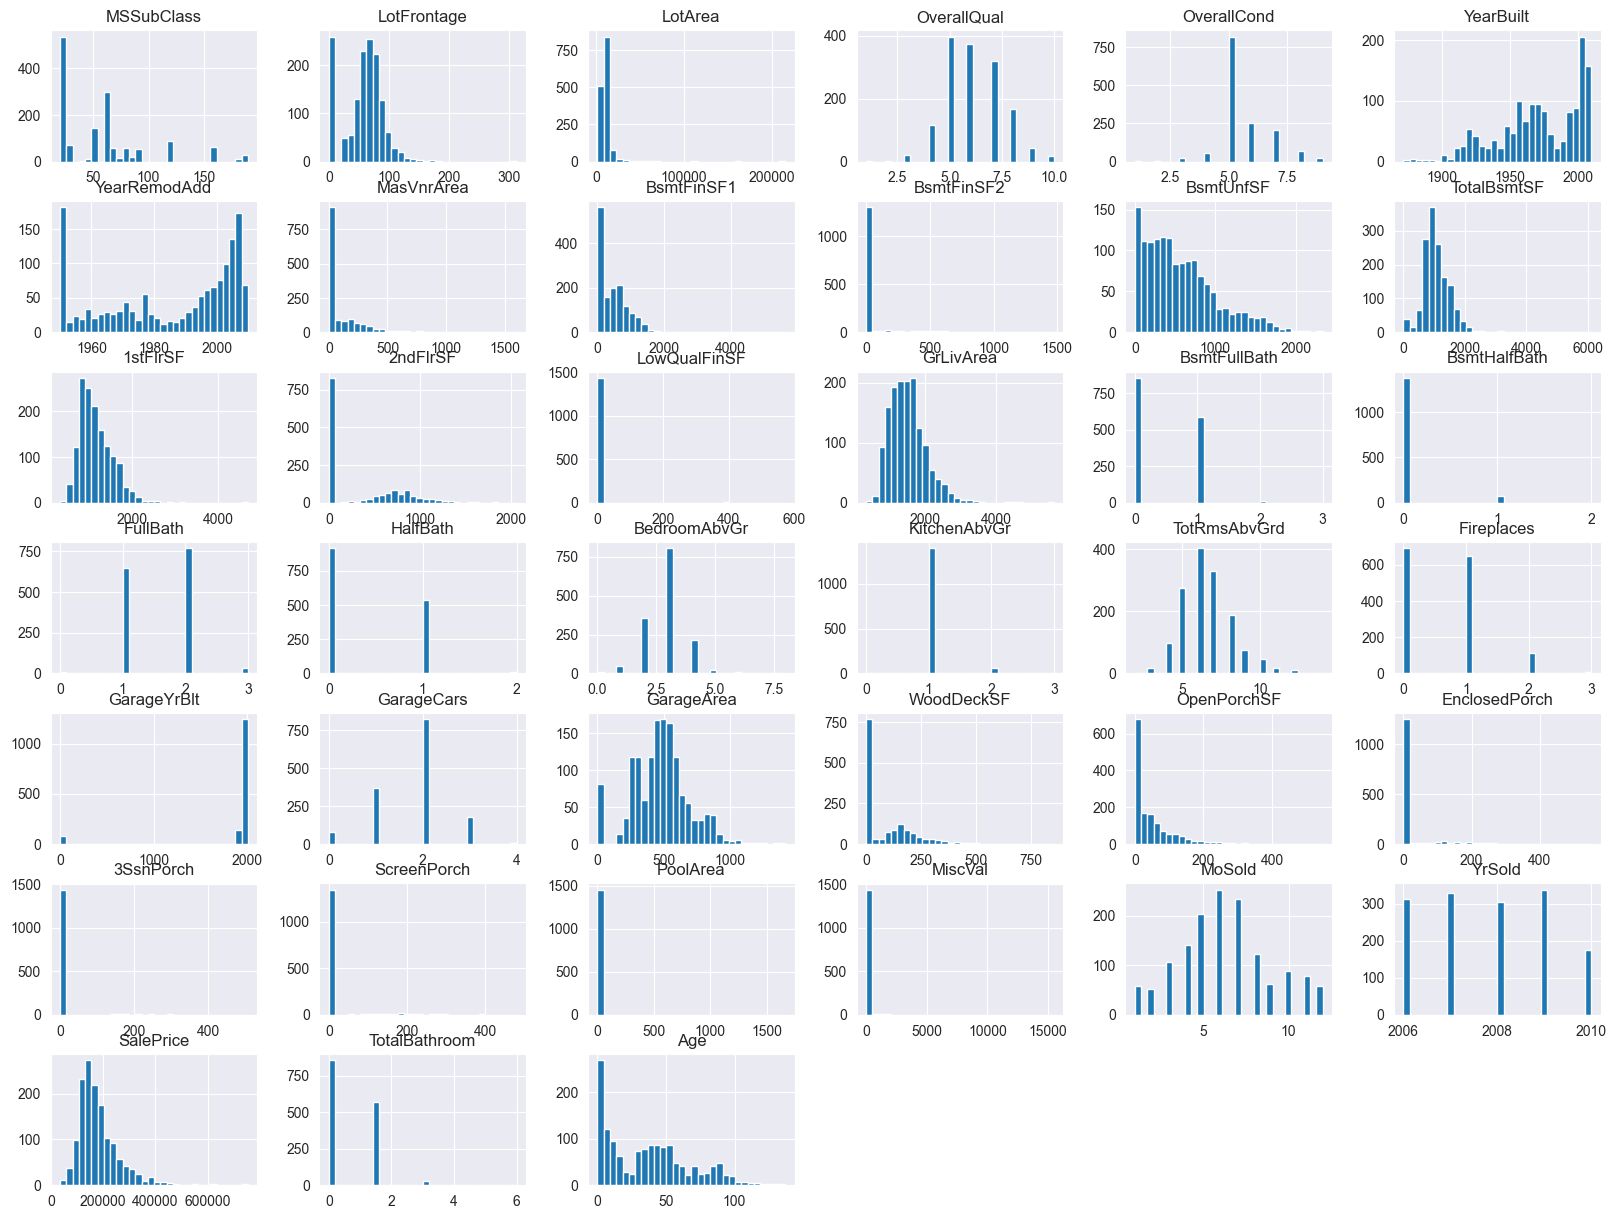

In [713]:
import matplotlib.pyplot as plt

data.hist(figsize=(20, 15), bins=30)
plt.show()

In [712]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score, mean_squared_error

data = data.sample(1460)

target = "SalePrice"

X = data.drop(columns=target)
y = data[target]

y = np.log1p(y)

# Encode categorical features
encoder = OrdinalEncoder()
categorical_features = X.select_dtypes("object").columns
X[categorical_features] = encoder.fit_transform(X[categorical_features])

# Manual split (80/20)
split_point = int(len(X) * 0.8)

X_train = X[:split_point]
X_test = X[split_point:]
y_train = y[:split_point]
y_test = y[split_point:]

model = GradientBoostingRegressor(n_estimators = 100, max_depth = 6)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(mean_squared_error(np.log(np.exp(y_test)-1) - 1, np.log(np.exp(y_pred)-1)-1)**0.5)
print(r2_score(np.exp(y_test)-1, np.exp(y_pred)-1))
print(pd.Series(model.feature_importances_, index = X.columns).sort_values(ascending = False))

0.12983171552392495
0.9182491569619428
OverallQual    0.520034
GrLivArea      0.126153
TotalBsmtSF    0.052834
GarageArea     0.031495
1stFlrSF       0.024656
                 ...   
MiscFeature    0.000005
Condition2     0.000003
Street         0.000000
Utilities      0.000000
Heating        0.000000
Length: 80, dtype: float64
